If I take a few of this large returns, what are the features of it?

Were these returns explained partly by past volatility?
Was it explained by the sector, market or industry?
Has it anything to do with headlines?

In [3]:
import pandas as pd
import numpy as np

In [4]:
extreme_returns = pd.read_csv("data/sp500_pct_extremes.csv")

extreme_returns

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,arithmetic_return_%,log_return,index,Dividends,Stock Splits,z_score_global,extreme
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,-53.864746,-0.773593,NaN,NaN,NaN,-39.923853,True
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,-53.140192,-0.758010,NaN,NaN,NaN,-39.120169,True
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,-52.359296,-0.741483,NaN,NaN,NaN,-38.267788,True
3,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,-52.013793,-0.734257,35302.0,0.79,0.0,-37.895106,True
4,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,-44.043751,-0.580600,NaN,NaN,NaN,-29.970347,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1728,2025-04-04,BKR,39.290001,39.680000,35.279999,35.410000,34.706951,20974600.0,40.048748,-0.133382,-13.338237,-0.143157,NaN,NaN,NaN,-7.409455,True
1729,2018-11-16,EIX,52.860001,55.009998,52.509998,54.450001,38.770332,8828700.0,33.600945,0.153847,15.384650,0.143101,NaN,NaN,NaN,7.354191,True
1730,2020-03-16,EIX,48.470001,51.110001,43.630001,46.150002,34.412170,4654000.0,39.706360,-0.133334,-13.333354,-0.143101,NaN,NaN,NaN,-7.406549,True
1731,2020-03-17,ATO,96.199997,108.330002,95.790001,108.089996,93.097412,1887700.0,80.686157,0.153821,15.382137,0.143079,NaN,NaN,NaN,7.353067,True


In [5]:
# is there unique stock contributing?

extreme_returns["Ticker"].nunique()

342

The SP500 is constituted of about ~500 stocks (like the name suggests but some stocks are dropping and some are introduced.).
There are 342 tickers in the large extremes, meaning that most stocks have wide swings. But it also means that about 160 stocks behave differently and do not have these wild volatility events.

# Time Clustering

In [6]:
# is a specific period dominating?

extreme_returns["year"] = pd.to_datetime(extreme_returns["Date"]).dt.year

extreme_by_year = (
    extreme_returns
    .groupby("year")
    .size()
    .rename("n_events")
)

extreme_by_year

year
2010     39
2011     73
2012     65
2013     51
2014     24
2015     53
2016     56
2017     37
2018     54
2019     61
2020    763
2021     20
2022     69
2023     51
2024     97
2025    176
2026     44
Name: n_events, dtype: int64

So a lot during bubble and crash years but also a lot during normal years. Keep in mind that this is 99.9th percentile.

In [7]:
events_per_day = (
    extreme_returns
    .groupby("Date")
    .size()
    .sort_values(ascending=False)
)

events_per_day.head(10)

Date
2020-03-16    185
2020-03-24     92
2020-03-18     80
2020-03-12     79
2020-03-09     46
2020-11-09     36
2020-03-13     35
2025-04-09     30
2020-03-19     25
2020-03-17     23
dtype: int64

The covid years have seen incredible volatility

# sectors and industries

In [8]:
# join the returns and ticker list dataset to have access to sectors and industries

sp500_list = pd.read_csv("data/sp500_list.csv")

extreme_sector_n_industries = pd.merge(
    extreme_returns,
    sp500_list,
    left_on="Ticker",
    right_on= "ticker",
    how="inner"
)

extreme_sector_n_industries.head()

,Date,Ticker,Open,High,Low,Close,Adj Close,Volume,previous_adj_close,arithmetic_return,...,Dividends,Stock Splits,z_score_global,extreme,year,ticker,company_name,sector,industry,index_y
0,2020-03-09,APA,13.420000,13.700000,9.320000,9.550000,8.224354,28073200.0,17.826614,-0.538647,...,NaN,NaN,-39.923853,True,2020,APA,APA Corporation,Energy,Oil & Gas Exploration & Production,S&P500
1,2024-04-11,GL,98.480003,98.580002,38.950001,49.169998,48.298512,36577500.0,103.070229,-0.531402,...,NaN,NaN,-39.120169,True,2024,GL,Globe Life,Financials,Life & Health Insurance,S&P500
2,2019-01-14,PCG,9.210000,9.730000,7.780000,8.380000,8.260254,127198800.0,17.338648,-0.523593,...,NaN,NaN,-38.267788,True,2019,PCG,PG&E Corporation,Utilities,Multi-Utilities,S&P500
3,2020-03-09,OXY,15.580000,19.190001,12.040000,12.510000,11.708246,104930300.0,24.399191,-0.520138,...,0.79,0.0,-37.895106,True,2020,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,S&P500
4,2025-10-29,FISV,71.360001,76.650002,66.580002,70.599998,70.599998,103454200.0,126.169998,-0.440438,...,NaN,NaN,-29.970347,True,2025,FISV,Fiserv,Financials,Transaction & Payment Processing Services,S&P500


# Raw count by sectors
First, non normalized

In [9]:
events_by_sector = (
    extreme_sector_n_industries
    .groupby("sector")
    .size()
    .sort_values(ascending=False)
)

events_by_sector

sector
Information Technology    410
Consumer Discretionary    274
Industrials               198
Health Care               175
Financials                172
Energy                    118
Communication Services     88
Real Estate                77
Utilities                  75
Materials                  74
Consumer Staples           72
dtype: int64

In [10]:
# here we need to be sure that the "buckets" of industries and sectors are about the same size so we normalize
# the problem did not appear for time clustering because each stock is quoted every day (few halting exceptions I decided to not consider)

# count per sector
stocks_per_sector = (
    sp500_list
    .groupby("sector")["ticker"]
    .nunique()
)

events_per_sector = extreme_sector_n_industries.groupby("sector").size()

intensity = (events_per_sector / stocks_per_sector).sort_values(ascending=False)

intensity

sector
Consumer Discretionary    5.708333
Information Technology    5.616438
Energy                    5.363636
Communication Services    3.826087
Health Care               3.017241
Materials                 2.846154
Industrials               2.506329
Real Estate               2.483871
Utilities                 2.419355
Financials                2.263158
Consumer Staples          2.000000
Index                          NaN
dtype: float64

Energy which was in the middle of the pack suddenly becomes quite volatile.

# Count by Industries

In [11]:
events_per_industries = (
    extreme_sector_n_industries
    .groupby("industry")
    .size()
    .sort_values(ascending=False)
)

events_per_industries

industry
Semiconductors                                127
Technology Hardware, Storage & Peripherals     92
Hotels, Resorts & Cruise Lines                 77
Oil & Gas Exploration & Production             65
Health Care Equipment                          58
                                             ... 
Industrial REITs                                1
Reinsurance                                     1
Self-Storage REITs                              1
Tobacco                                         1
Water Utilities                                 1
Length: 112, dtype: int64

In [12]:
# normalized
# I need to inner join both because some industries have little stocks and hence none crossed the 4 sigma

stocks_per_industries = (
    sp500_list
    .groupby("industry")["ticker"]
    .nunique()
)

events_per_industries, stocks_per_industries = events_per_industries.align(
    stocks_per_industries,
    join="inner"
)

intensity = (events_per_industries / stocks_per_industries).sort_values(ascending=False)



In [13]:
intensity

industry
Footwear                         17.0
Copper                           13.0
Computer & Electronics Retail    13.0
Homefurnishing Retail            11.0
Movies & Entertainment           10.6
                                 ... 
Household Products                0.5
Industrial Gases                  0.5
Industrial Conglomerates          0.5
Self-Storage REITs                0.5
Tobacco                           0.5
Length: 112, dtype: float64

# Pragmatic questions for investors

In [14]:
# -----------------------------
# 2. Define direction of returns
# -----------------------------
# Positive = 1, Negative = -1
extreme_returns["direction"] = np.where(
    extreme_returns["arithmetic_return"] > 0,
    "positive",
    "negative"
)

# -----------------------------
# 3. Count extreme events per year and direction
# -----------------------------
yearly_sign = (
    extreme_returns
    .groupby(["year", "direction"])
    .size()
    .unstack(fill_value=0)
)

# -----------------------------
# 4. Add useful metrics
# -----------------------------

# Net imbalance: positive - negative extremes
yearly_sign["net"] = yearly_sign["positive"] - yearly_sign["negative"]

# Ratio of positive extremes (avoid division issues)
yearly_sign["ratio_positive"] = (
    yearly_sign["positive"] /
    (yearly_sign["positive"] + yearly_sign["negative"])
)

# -----------------------------
# 5. Optional: magnitude-based view
# -----------------------------

# Mean extreme return per year (signed)
yearly_mean_return = (
    extreme_returns
    .groupby("year")["arithmetic_return"]
    .mean()
)

# Median extreme return per year (robust to outliers)
yearly_median_return = (
    extreme_returns
    .groupby("year")["arithmetic_return"]
    .median()
)

# -----------------------------
# 6. Combine everything into one table (optional)
# -----------------------------
yearly_analysis = yearly_sign.copy()
yearly_analysis["mean_return"] = yearly_mean_return
yearly_analysis["median_return"] = yearly_median_return

# -----------------------------
# 7. Output
# -----------------------------
print(yearly_analysis.sort_index())

direction  negative  positive  net  ratio_positive  mean_return  median_return
year                                                                          
2010             17        22    5        0.564103     0.031845       0.157985
2011             44        29  -15        0.397260    -0.028640      -0.136593
2012             39        26  -13        0.400000    -0.018324      -0.142348
2013             22        29    7        0.568627     0.058693       0.163800
2014             10        14    4        0.583333     0.039891       0.163257
2015             29        24   -5        0.452830     0.001410      -0.137258
2016             34        22  -12        0.392857    -0.024321      -0.142418
2017             20        17   -3        0.459459    -0.003148      -0.134737
2018             32        22  -10        0.407407    -0.024015      -0.143601
2019             35        26   -9        0.426230    -0.021647      -0.139680
2020            479       284 -195        0.372215  

In [15]:
# mean direction
sector_mean = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .mean()
)

# median (robust)
sector_median = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .median()
)

# % positive
sector_pos_ratio = (
    extreme_sector_n_industries
    .groupby("sector")["arithmetic_return"]
    .apply(lambda x: (x > 0).mean())
)

print("Mean and median extreme returns show more negative. With a slight right skew.\n")
print(sector_mean,"\n")
print(sector_median,"\n")
print("The probabilites of having a positive extreme return are less than a negative one. But not by much.\n")
print(sector_pos_ratio)

Mean and median extreme returns show more negative. With a slight right skew.

sector
Communication Services    0.027126
Consumer Discretionary   -0.028124
Consumer Staples         -0.051116
Energy                   -0.015590
Financials               -0.047232
Health Care              -0.029494
Industrials              -0.025042
Information Technology   -0.006803
Materials                -0.028583
Real Estate              -0.053957
Utilities                -0.043139
Name: arithmetic_return, dtype: float64 

sector
Communication Services    0.154835
Consumer Discretionary   -0.141140
Consumer Staples         -0.144654
Energy                   -0.138532
Financials               -0.141504
Health Care              -0.143289
Industrials              -0.139838
Information Technology   -0.137211
Materials                -0.142768
Real Estate              -0.152597
Utilities                -0.139830
Name: arithmetic_return, dtype: float64 

The probabilites of having a positive extreme return 

# Visualization

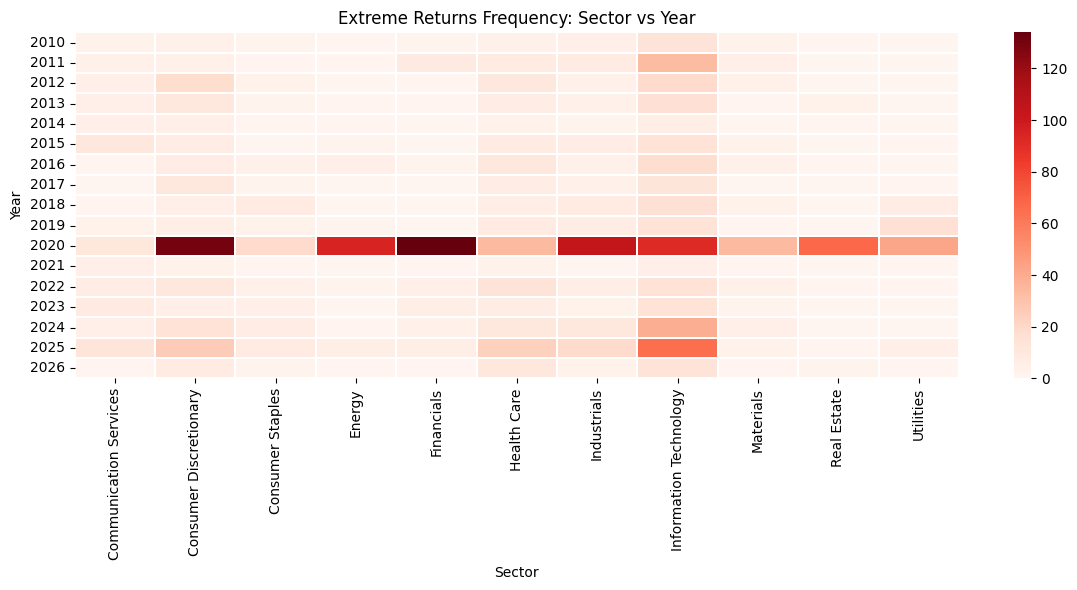

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# -----------------------------
# Year x Sector counts
# -----------------------------
year_sector = (
    extreme_sector_n_industries
    .groupby(["year", "sector"])
    .size()
    .unstack(fill_value=0)
)

plt.figure(figsize=(12, 6))
sns.heatmap(year_sector, cmap="Reds", linewidths=0.2)

plt.title("Extreme Returns Frequency: Sector vs Year")
plt.xlabel("Sector")
plt.ylabel("Year")
plt.tight_layout()
plt.show()

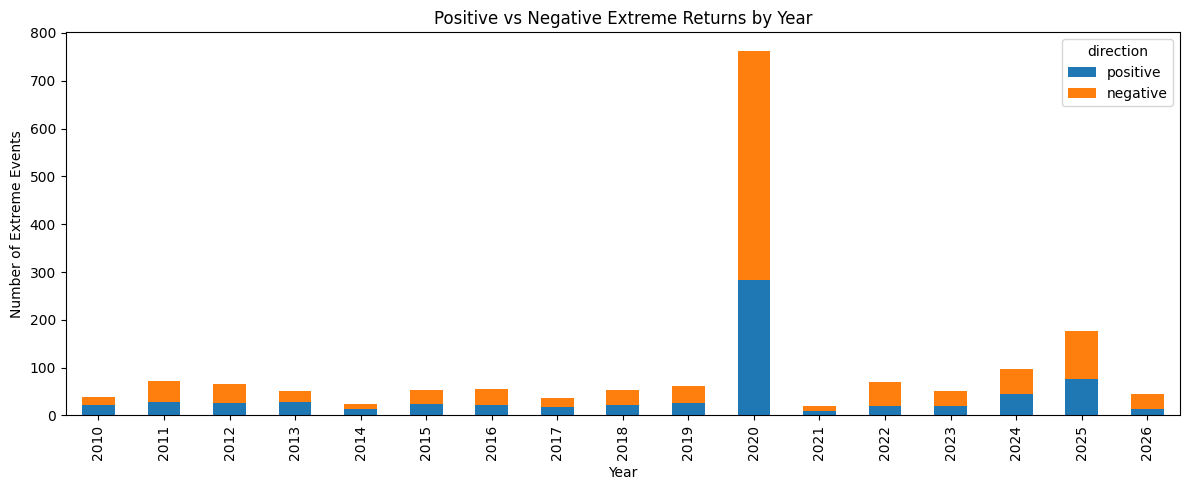

In [17]:
yearly_sign[["positive", "negative"]].plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Positive vs Negative Extreme Returns by Year")
plt.xlabel("Year")
plt.ylabel("Number of Extreme Events")
plt.tight_layout()
plt.show()

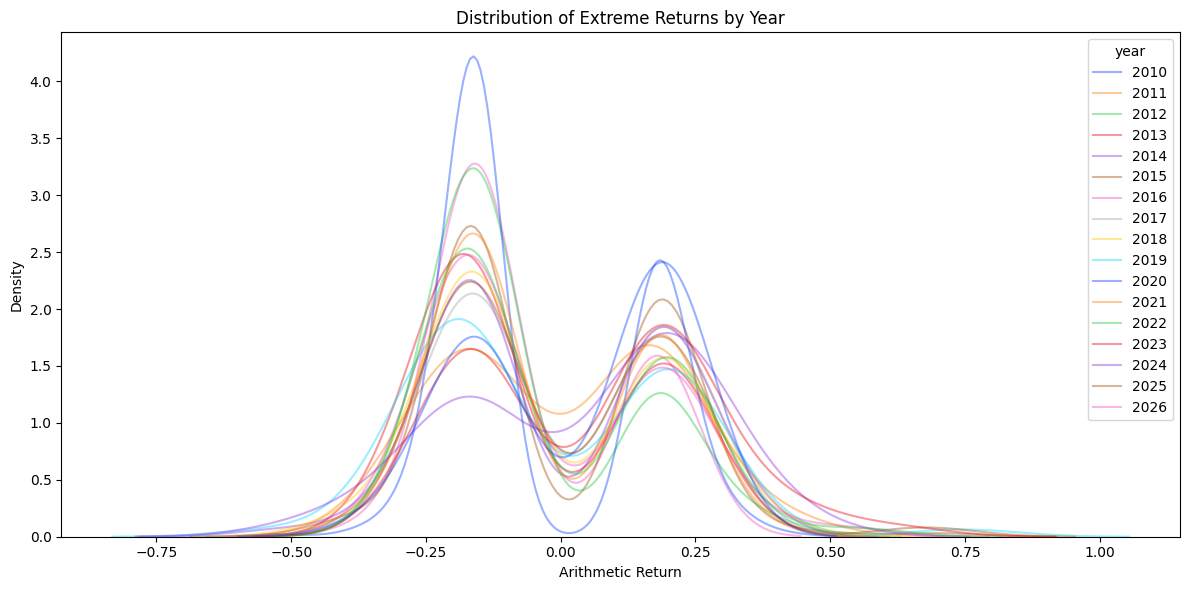

In [18]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=extreme_returns,
    x="arithmetic_return",
    hue="year",
    common_norm=False,
    alpha=0.4,
    palette="bright"
)

plt.title("Distribution of Extreme Returns by Year")
plt.xlabel("Arithmetic Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()

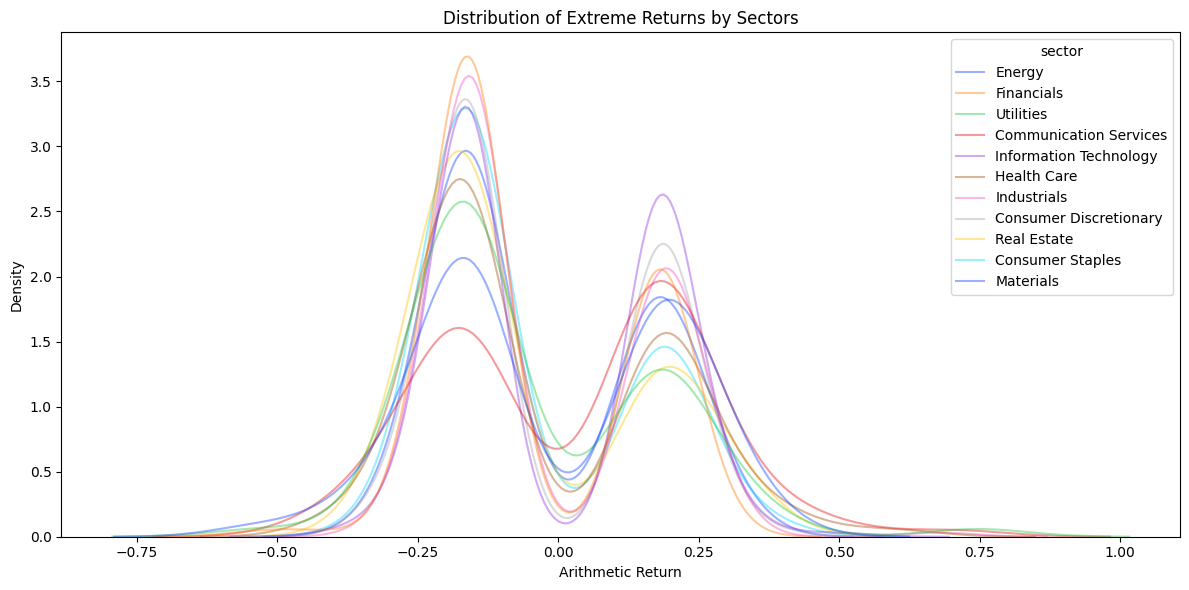

In [21]:
plt.figure(figsize=(12, 6))

sns.kdeplot(
    data=extreme_sector_n_industries,
    x="arithmetic_return",
    hue="sector",
    common_norm=False,
    alpha=0.4,
    palette="bright"
)

plt.title("Distribution of Extreme Returns by Sectors")
plt.xlabel("Arithmetic Return")
plt.ylabel("Density")
plt.tight_layout()
plt.show()